# YOLO 추론

- 이미지 분류 추론
- 원본 스크립트: `predict_yolo_cls.py`

YOLO Classification 추론 스크립트

학습된 YOLO 분류 모델로 이미지를 예측합니다.

사용법:
    - `python scripts/predict_yolo_cls.py --model runs/classify/fine_cls_v2/weights/best.pt --source dataset/icons/images/...`
    - `python scripts/predict_yolo_cls.py --model runs/classify/fine_cls_v2/weights/best.pt --source dataset/icons/images --save-txt`

In [1]:
from __future__ import annotations

import argparse
import json
import sys
from pathlib import Path
from typing import Any, Dict, List

from ultralytics import YOLO

# ---- Helpers ----

def ensure_file(path: Path) -> Path:
    if not path.is_file():
        raise FileNotFoundError(f"파일이 없습니다: {path}")
    return path


def ensure_dir(path: Path) -> Path:
    if not path.is_dir():
        raise FileNotFoundError(f"디렉터리가 없습니다: {path}")
    return path


def find_latest_run(base: Path) -> Path:
    import re

    numbered = []
    for p in base.iterdir():
        if not p.is_dir():
            continue
        m = re.match(r"^yolo-cls(\d+)$", p.name)
        if m:
            numbered.append((int(m.group(1)), p))
    if numbered:
        return max(numbered, key=lambda t: t[0])[1]
    candidates = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else base / "yolo-cls"


def load_class_names(data_dir: Path, mode: str) -> Dict[int, str]:
    mapping_path = data_dir / f"class_mapping_{mode}.json"
    if not mapping_path.exists():
        print(f"[WARN] 클래스 매핑 파일이 없습니다: {mapping_path}")
        return {}
    with mapping_path.open("r", encoding="utf-8") as f:
        mapping = json.load(f)
    id_to_fine = mapping.get("id_to_fine", {})
    return {int(k): v for k, v in id_to_fine.items()}


def collect_image_paths(source: Path) -> List[Path]:
    if source.is_dir():
        exts = {".png", ".jpg", ".jpeg", ".webp"}
        paths = [p for p in source.rglob("*") if p.suffix.lower() in exts]
    elif source.is_file():
        paths = [source]
    else:
        # glob 패턴 지원
        paths = list(source.parent.glob(source.name))
    return sorted(paths)

In [2]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="YOLO-CLS 추론")
    parser.add_argument("--model", type=Path, default=None, help="best.pt 경로. 미지정 시 최신 yolo-cls* 사용")
    parser.add_argument("--mode", choices=["fine", "coarse"], default="fine")
    parser.add_argument("--data-dir", type=Path, default=Path("./dataset/icons"))
    parser.add_argument("--source", type=Path, default=Path("./dataset/icons/images"))
    parser.add_argument("--imgsz", type=int, default=256)
    parser.add_argument("--conf", type=float, default=0.25)
    parser.add_argument("--device", default=None)
    parser.add_argument("--top-k", type=int, default=5)
    parser.add_argument("--save-json", action="store_true")
    parser.add_argument("--save-txt", action="store_true")
    parser.add_argument("--save-dir", type=Path, default=None)
    return parser.parse_args(args=[])


# ----- Config -----
args = parse_args()

base_runs = Path("runs/classify").resolve()
latest_run = find_latest_run(base_runs)

# model fallback
if args.model:
    MODEL_PATH = ensure_file(args.model)
else:
    MODEL_PATH = ensure_file(latest_run / "weights" / "best.pt")

MODE = args.mode
DATA_DIR = ensure_dir(args.data_dir)
YOLO_DATA_DIR = ensure_dir(DATA_DIR / f"yolo_cls_{MODE}")
SOURCE = args.source
IMGSZ = args.imgsz
CONF = args.conf
DEVICE = args.device
TOP_K = args.top_k
SAVE_JSON = args.save_json
SAVE_TXT = args.save_txt
SAVE_DIR = args.save_dir or MODEL_PATH.parent.parent / "predict"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = load_class_names(DATA_DIR, MODE)

print(f"[INFO] MODEL   = {MODEL_PATH}")
print(f"[INFO] SOURCE  = {SOURCE}")
print(f"[INFO] MODE    = {MODE}")
print(f"[INFO] IMGSZ   = {IMGSZ}, CONF={CONF}, TOP_K={TOP_K}")
print(f"[INFO] SAVE DIR= {SAVE_DIR}")
print(f"[INFO] latest run = {latest_run.name}")

[INFO] MODEL   = /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/weights/best.pt
[INFO] SOURCE  = dataset/icons/images
[INFO] MODE    = fine
[INFO] IMGSZ   = 256, CONF=0.25, TOP_K=5
[INFO] SAVE DIR= /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/predict
[INFO] latest run = yolo-cls16


In [3]:
def main():
    image_paths = collect_image_paths(SOURCE)
    if not image_paths:
        print(f"[ERROR] 이미지 파일을 찾을 수 없습니다: {SOURCE}")
        sys.exit(1)

    print("=" * 80)
    print("YOLO Classification 추론")
    print("=" * 80)
    print(f"모델          : {MODEL_PATH}")
    print(f"입력          : {SOURCE}")
    print(f"이미지 개수   : {len(image_paths)}")
    print(f"모드          : {MODE}")
    print(f"이미지 크기   : {IMGSZ}")
    print(f"신뢰도 임계값 : {CONF}")
    print(f"Top-K         : {TOP_K}")
    print(f"저장 디렉터리 : {SAVE_DIR}")
    print("=" * 80)

    print(f"\n[1/3] 모델 로드: {MODEL_PATH}")
    model = YOLO(str(MODEL_PATH))

    print(f"[2/3] 추론 중... ({len(image_paths)}개 이미지)")
    results_list: List[Dict[str, Any]] = []

    try:
        for i, img_path in enumerate(image_paths, 1):
            if i % 10 == 0:
                print(f"  진행: {i}/{len(image_paths)}")

            results = model.predict(
                source=str(img_path),
                imgsz=IMGSZ,
                conf=CONF,
                device=DEVICE,
                verbose=False,
                save=True,
                save_dir=str(SAVE_DIR),
            )

            if not results:
                continue

            result = results[0]
            if hasattr(result, "probs") and result.probs is not None:
                probs = result.probs.data.cpu().numpy()
                top_k_indices = probs.argsort()[-TOP_K:][::-1]
                top_k_probs = probs[top_k_indices]

                predictions = []
                for idx, prob in zip(top_k_indices, top_k_probs):
                    class_name = CLASS_NAMES.get(int(idx), f"class_{idx}")
                    predictions.append(
                        {
                            "class_id": int(idx),
                            "class_name": class_name,
                            "confidence": float(prob),
                        }
                    )

                result_dict = {
                    "image_path": str(img_path),
                    "predictions": predictions,
                }
                results_list.append(result_dict)

                print(f"\n{img_path.name}:")
                for pred in predictions[:3]:
                    print(f"  {pred['class_name']}: {pred['confidence']:.4f}")

    except KeyboardInterrupt:
        print("\n[WARN] 사용자에 의해 추론이 중단되었습니다.")
    except Exception:
        import traceback

        traceback.print_exc()
        sys.exit(1)

    # 결과 저장
    print(f"\n[3/3] 결과 저장...")
    if SAVE_JSON:
        json_path = SAVE_DIR / "predictions.json"
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(results_list, f, indent=2, ensure_ascii=False)
        print(f"  JSON 저장: {json_path}")

    if SAVE_TXT:
        txt_path = SAVE_DIR / "predictions.txt"
        with open(txt_path, "w", encoding="utf-8") as f:
            for result in results_list:
                f.write(f"{result['image_path']}\n")
                for pred in result["predictions"]:
                    f.write(f"  {pred['class_name']}: {pred['confidence']:.4f}\n")
                f.write("\n")
        print(f"  텍스트 저장: {txt_path}")

    print("\n" + "=" * 80)
    print("추론 완료!")
    print("=" * 80)
    print(f"처리된 이미지: {len(results_list)}/{len(image_paths)}")
    print(f"결과 디렉터리: {SAVE_DIR}")
    print("=" * 80)


if __name__ == "__main__":
    main()

YOLO Classification 추론
모델          : /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/weights/best.pt
입력          : dataset/icons/images
이미지 개수   : 1395
모드          : fine
이미지 크기   : 256
신뢰도 임계값 : 0.25
Top-K         : 5
저장 디렉터리 : /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/predict

[1/3] 모델 로드: /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/weights/best.pt
[2/3] 추론 중... (1395개 이미지)
Results saved to /home/wsm/workspace/hit-aws-object-detection-project/runs/classify/predict3

Arch_Amazon-Bedrock_16.png:
  amazon opensearch service: 0.4261
  aws snowball: 0.2476
  aws cloud map: 0.0735
Results saved to /home/wsm/workspace/hit-aws-object-detection-project/runs/classify/predict3

Arch_Amazon-Bedrock_32.png:
  amazon opensearch service: 0.4355
  aws snowball: 0.1901
  aws cloud map: 0.1025
Results saved to /home/wsm/workspace/hit-aws-object-detection-project/runs/classify/predict3

Arch_Amazon-Bedrock_48.png:
  amazon opensearch servi

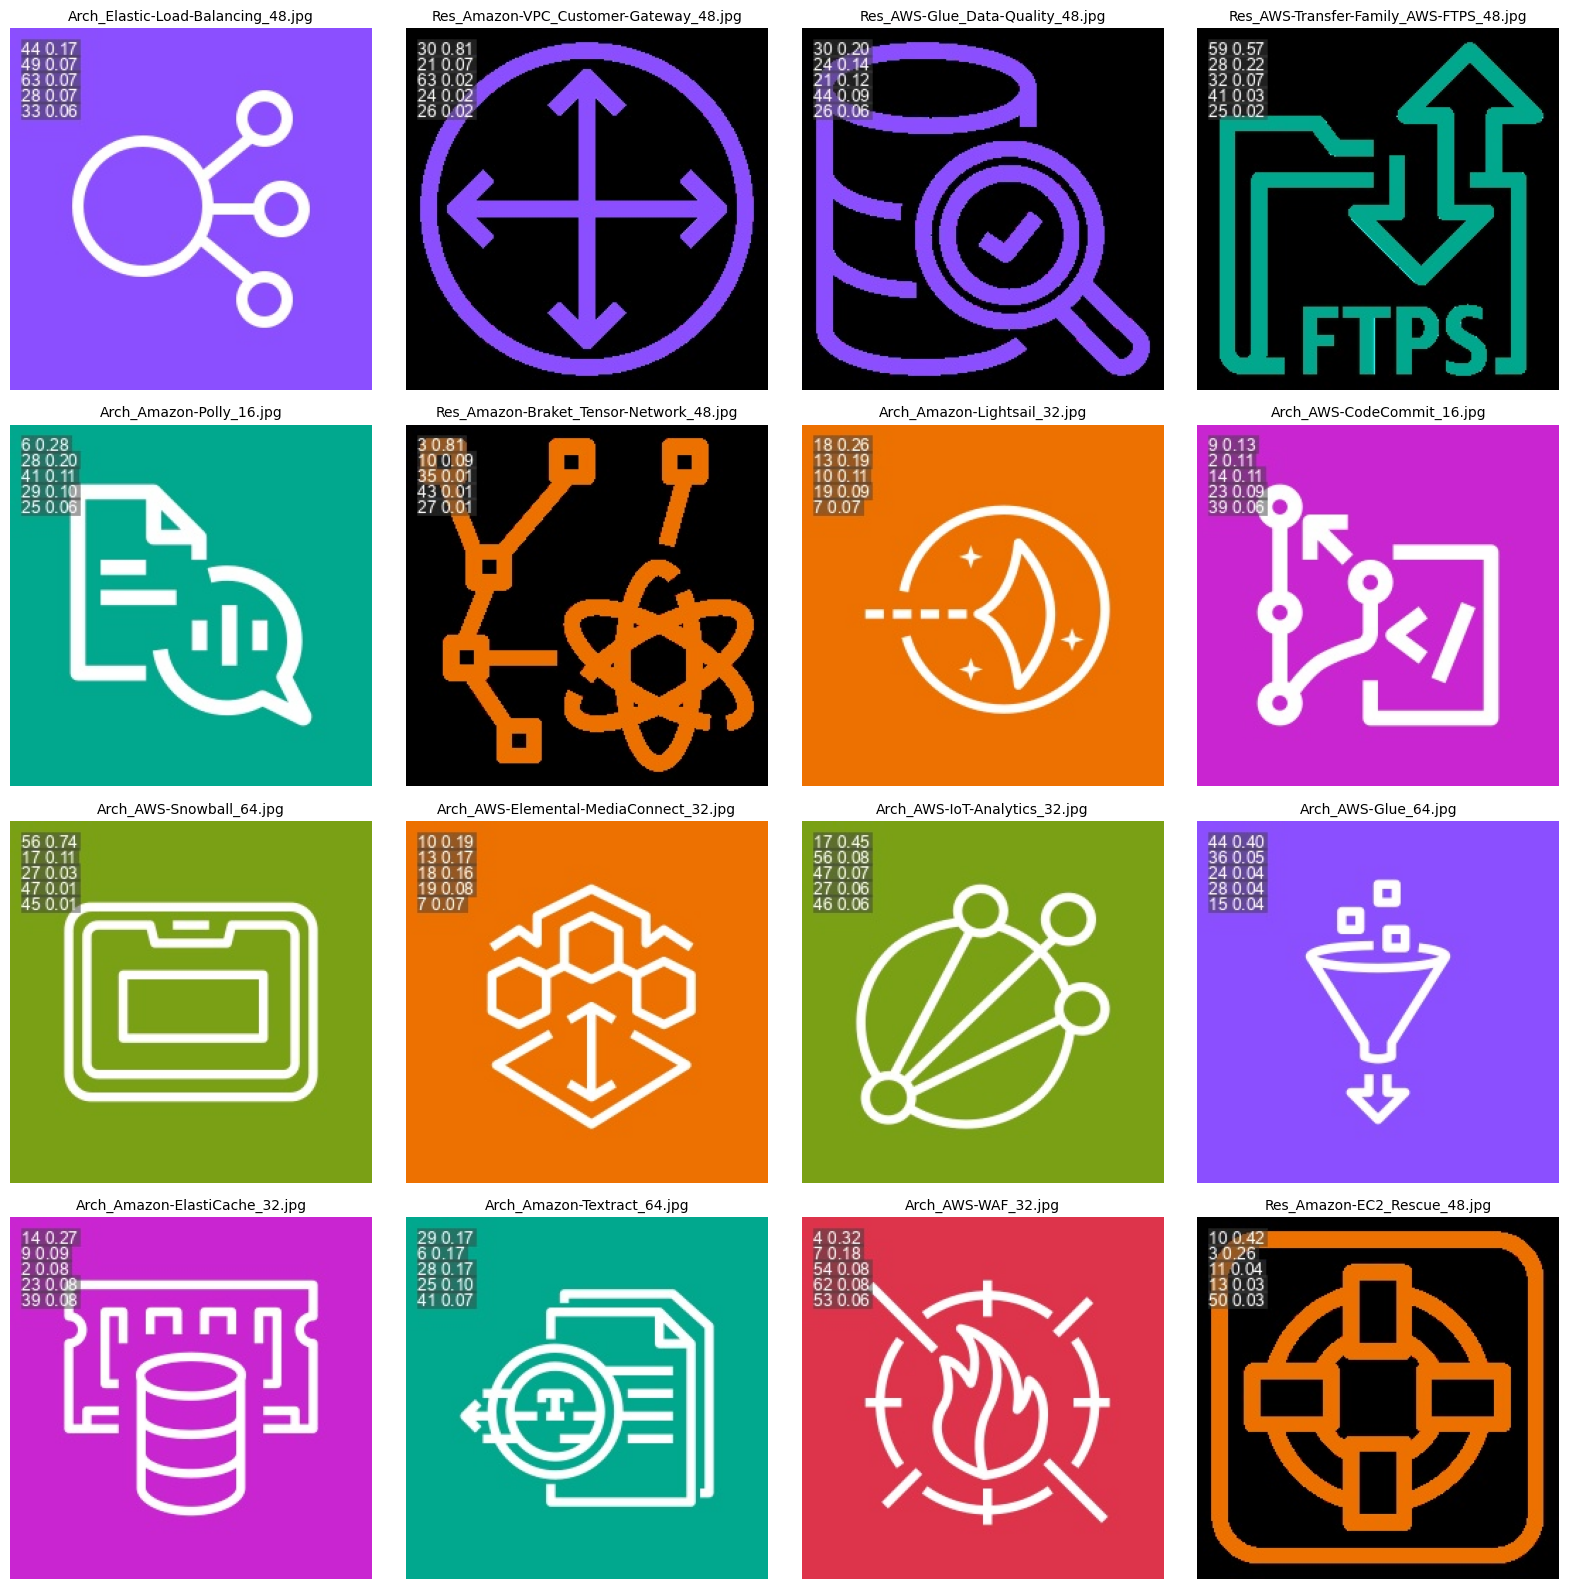

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pathlib
import math

def show_example_images_from_predict_dir(predict_dir, num_rows=4, num_cols=4):
    """
    지정된 predict_dir 폴더에서 예시 결과 사진을 4x4(기본값, 최대 16장) 격자로 모아서 보여줍니다.
    """
    predict_dir = pathlib.Path(predict_dir)
    # 지원하는 이미지 확장자
    image_exts = [".jpg", ".jpeg", ".png", ".bmp"]
    image_files = [p for p in predict_dir.iterdir() if p.suffix.lower() in image_exts]
    if not image_files:
        print(f"'{predict_dir}' 폴더에 이미지가 없습니다.")
        return

    num_images = min(num_rows * num_cols, len(image_files))
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))

    for idx in range(num_rows * num_cols):
        row = idx // num_cols
        col = idx % num_cols
        ax = axs[row, col] if num_rows > 1 else axs[col]
        if idx < num_images:
            img = mpimg.imread(str(image_files[idx]))
            ax.imshow(img)
            ax.set_title(image_files[idx].name, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 사용 예시:
show_example_images_from_predict_dir("/home/wsm/workspace/hit-aws-object-detection-project/runs/classify/predict")

In [21]:
# 라벨 클래스 id -> 이름 매핑을 `data/classes.txt`로 보강
from pathlib import Path
from typing import Dict


def load_class_list(class_list_path: Path) -> Dict[int, str]:
    """줄 단위 클래스 리스트를 id->이름 매핑으로 변환"""
    if not class_list_path.exists():
        return {}
    lines = [ln.strip() for ln in class_list_path.read_text().splitlines() if ln.strip()]
    return {idx: name for idx, name in enumerate(lines)}


def print_label_with_name(
    label_path: str,
    mode: str = "fine",
    data_dir: str = "./dataset/icons",
    class_list_path: str | None = "/home/wsm/workspace/hit-archlens-project/data/classes.txt",
) -> None:
    """단일 라벨(.txt) 파일을 읽어 클래스 번호와 이름, 점수를 표시"""
    label_path = Path(label_path)
    class_names: Dict[int, str] = load_class_names(Path(data_dir), mode)
    if class_list_path:
        class_names.update(load_class_list(Path(class_list_path)))

    if not label_path.exists():
        print(f"[WARN] 라벨 파일이 없습니다: {label_path}")
        return

    lines = [ln.strip() for ln in label_path.read_text().splitlines() if ln.strip()]
    if not lines:
        print(f"[WARN] 라벨 내용이 없습니다: {label_path}")
        return

    print(f"[INFO] {label_path}")
    for ln in lines:
        parts = ln.split()
        if len(parts) < 2:
            print(f"  {ln} (형식 불일치)")
            continue
        class_id = int(float(parts[0]))
        conf = float(parts[1])
        cls_name = class_names.get(class_id, f"class_{class_id}")
        print(f"  {class_id} ({cls_name}): {conf:.4f}")


def preview_label_dir(
    label_dir: str,
    max_files: int = 3,
    mode: str = "fine",
    data_dir: str = "./dataset/icons",
    class_list_path: str | None = "/home/wsm/workspace/hit-archlens-project/data/classes.txt",
) -> None:
    """predict/labels 폴더에서 앞부분 몇 개 파일을 예시로 출력"""
    label_dir_path = Path(label_dir)
    label_files = sorted(label_dir_path.glob("*.txt"))
    if not label_files:
        print(f"[WARN] 라벨 파일이 없습니다: {label_dir_path}")
        return

    for label_file in label_files[:max_files]:
        print_label_with_name(
            str(label_file),
            mode=mode,
            data_dir=data_dir,
            class_list_path=class_list_path,
        )
        print()


# 사용 예시 (경로만 맞춰 실행)
preview_label_dir(
    "/home/wsm/workspace/hit-archlens-project/data/labels",
    mode="fine",
    data_dir="/home/wsm/workspace/hit-archlens-project/dataset/icons",
    class_list_path="/home/wsm/workspace/hit-archlens-project/data/classes.txt",
)
print_label_with_name(
    "/home/wsm/workspace/hit-archlens-project/data/labels/00022aa2-imgi_469_images.txt",
    mode="fine",
    data_dir="/home/wsm/workspace/hit-archlens-project/dataset/icons",
    class_list_path="/home/wsm/workspace/hit-archlens-project/data/classes.txt",
)


[INFO] /home/wsm/workspace/hit-archlens-project/data/labels/00022aa2-imgi_469_images.txt
  94 (sagemaker): 0.4293
  94 (sagemaker): 0.4308
  94 (sagemaker): 0.4286
  91 (s3): 0.3103
  91 (s3): 0.7009
  91 (s3): 0.7024
  24 (cloudwatch): 0.7075

[INFO] /home/wsm/workspace/hit-archlens-project/data/labels/004299c4-imgi_450_images.txt
  91 (s3): 0.0978
  91 (s3): 0.5498
  69 (lambda): 0.2278
  69 (lambda): 0.7016
  102 (sns): 0.5520
  50 (eventbridge): 0.5498
  50 (eventbridge): 0.5512

[INFO] /home/wsm/workspace/hit-archlens-project/data/labels/019a95c1-imgi_520_images.txt
  90 (route 53): 0.0143
  22 (cloudfront): 0.2408
  91 (s3): 0.4113
  91 (s3): 0.5873
  40 (dynamodb): 0.3035
  40 (dynamodb): 0.6910
  48 (elb): 0.2422
  48 (elb): 0.7497
  45 (eks): 0.1842
  45 (eks): 0.3042
  45 (eks): 0.6889
  45 (eks): 0.8029
  47 (elasticache): 0.1855
  47 (elasticache): 0.3042
  47 (elasticache): 0.6883
  47 (elasticache): 0.8049
  9 (aurora): 0.6883
  9 (aurora): 0.8035
  9 (aurora): 0.3029
  9